In [ ]:
# Author: Mengkun Tian
# Script description:
# Convert the image from dm3,dm4, tif, png, jpg, jpeg to png (tif, jpg and jpeg are also allowed) with designated output format

import csv
import hashlib
import ast
import hyperspy.api as hs
import numpy as np
import tkinter as tk
from tkinter import filedialog,messagebox
from PIL import Image
from pathlib import Path
from typing import Any, Dict, List, Optional, Tuple, Union
from datetime import datetime

class ImageConverter:
    def __init__(self,select_input_dir=True,select_output_dir = True, output_format = 'png', output_size = (512,512), pixel_size_unit = 'nm', input_path: Optional[Union[str, Path]] = None, output_path: Optional[Union[str, Path]] = None, include_subfolders: Optional[bool] = None):
        """
        select_input_dir: True  -> user chooses input directory via dialog
                     False -> use current directory ('.') as input
        set_outputdir: True  -> user chooses output directory via dialog / overwrite prompt
                      False -> auto: <input_parent>/converted_images/<input_dir_name>
        """
        self.supported_input_formats = ('dm3','dm4','tif','png','jpg','jpeg','gif')
        self.supported_output_formats = ('tif','png','jpg','jpeg','gif')
        self.output_format = output_format.lower()
        if self.output_format not in self.supported_output_formats:
            raise ValueError(f"Output format {self.output_format} is not supported. Supported formats include 'tif','png','jpg','jpeg.'")
        self.output_size = output_size
        self.pixel_size_unit = self._normalize_scale_unit(pixel_size_unit)
        self.select_input_dir = select_input_dir
        self.select_output_dir = select_output_dir
        self.input_path: Optional[Path] = self._resolve_directory_path(input_path) if input_path is not None else None   # directory input
        self.output_path: Optional[Path] = self._resolve_directory_path(output_path) if output_path is not None else None  # directory output
        self.input_data= None # input_data and a flag. True if input_data is given. Output image will created at the same directory as the input data ending with '_resized'.
        self.image_registration: Dict[str, Dict[str, Any]] = {} # register original data: the image names, pixel size (if dm3 or dm4 data), dimension. and register the image after conversion: the image names, pixel size (if dm3 or dm4 data), dimensions. This will output as cvs file for every update of image. If the input dimension, or other information is unknown, it can allow user to manually input the information. This will be helpful for future image analysis and processing. Note everytime when csv be updated and overwritten, it will pop out a msg box. Also, the mannual input part will not be overwrite automatically unless we click update button when change happened in the mannual input part.
        self.registration_csv_path: Optional[Path] = None
        self.selected_files: Optional[List[Union[str, Path]]] = None
        self.include_subfolders: Optional[bool] = include_subfolders
        self._overwrite_existing_files: Optional[str] = None
        self._overwrite_registration_records: Optional[str] = None

    def _resolve_directory_path(self, directory_path: Optional[Union[str, Path]]) -> Optional[Path]:
        if directory_path is None:
            return None
        directory_text = str(directory_path).strip()
        if directory_text.lower() in ('current', './', '.', ''):
            return Path('.').resolve()
        return Path(directory_path).expanduser().resolve()

    def _select_directory_with_dialog(self, title: str, initialdir: Union[str, Path] = '.') -> Path:
        dialog_root = tk.Tk()
        dialog_root.withdraw()
        selected_dir = filedialog.askdirectory(title=title, initialdir=str(initialdir))
        dialog_root.destroy()
        if not selected_dir:
            raise RuntimeError(f'Please select a folder for: {title}')
        return Path(selected_dir).resolve()

    def _set_input_dir(self) -> Path:
        dialog_root = tk.Tk()
        dialog_root.withdraw()
        selected_dir = filedialog.askdirectory(title = 'Please choose the input directory.',initialdir = '.')
        dialog_root.destroy()
        # if no directory selected
        if not selected_dir:
            raise RuntimeError('Please select the input directory.')
        return Path(selected_dir).resolve()

    def _set_output_dir(self)-> Path:
        """
        Working directory is the input directory
        Default_dir is the working directory's parent / "converted_images"/ working directory
        If default directory not exist, system use the current directory's parent/ "converted_images" as output directory/current directory name.
        If default directory exist, ask user decide 1. ok: override the old existing directory; 2. no: choose another directory
        """
        if self.input_path is None:
            print('Input path is not selected. Automatically select the current directory as input.')
            self.input_path = Path('.').resolve()
        input_parent_dir = self.input_path.parent
        input_dir_name = self.input_path.name
        default_output_dir = input_parent_dir / "converted_images"/input_dir_name
        if default_output_dir.exists() and any(default_output_dir.iterdir()): 
            dialog_root =tk.Tk()
            dialog_root.withdraw()
            use_default_output = messagebox.askyesno(
                title = "Output folder exists", 
                message = f"The folder:\n{default_output_dir}\n"
                f"already exists and is not empty.\n\n"
                f"Click 'Yes' to reuse it and confirm duplicated images one by one during saving,\n"
                f"or 'No' to choose a different output folder."
            )
            if use_default_output:
                # Existing files are not deleted here; duplicated output images will be handled later by the overwrite confirmation.
                default_output_dir.mkdir(parents=True,exist_ok = True)#https://docs.python.org/3/library/pathlib.html
                selected_dir = default_output_dir
            else:
                selected_dir = filedialog.askdirectory(initialdir='.',title = "Please choose another folder as output directory")
            dialog_root.destroy()
        else:
            default_output_dir.mkdir(parents=True,exist_ok = True)
            selected_dir = default_output_dir
        if not selected_dir:
            raise RuntimeError('Please select the output directory.')

        return Path(selected_dir).resolve()

    def _get_default_output_dir(self) -> Path:
        if self.input_path is None:
            self.input_path = Path('.').resolve()
        input_parent_dir = self.input_path.parent
        input_dir_name = self.input_path.name
        return input_parent_dir / "converted_images" / input_dir_name

    def _set_output_path_from_argument(self, output_path: Optional[Union[str, Path]] = None) -> None:
        if output_path is not None:
            self.output_path = self._resolve_directory_path(output_path)
            assert self.output_path is not None
            self.output_path.mkdir(parents=True, exist_ok=True)
            self._set_registration_csv_path_if_needed(self.output_path)

    def _resolve_selected_file_paths(self, selected_files: Optional[Union[str, Path, List[Union[str, Path]], Tuple[Union[str, Path], ...]]]) -> List[Path]:
        if selected_files is None:
            return []
        if self.input_path is None:
            self.input_path = Path('.').resolve()
        if isinstance(selected_files, (str, Path)):
            selected_items = [selected_files]
        else:
            selected_items = list(selected_files)
        selected_image_file_paths: List[Path] = []
        for selected_item in selected_items:
            selected_text = str(selected_item)
            selected_path = Path(selected_item)
            has_wildcard = any(wildcard_char in selected_text for wildcard_char in ('*', '?', '['))
            if has_wildcard:
                if selected_path.is_absolute():
                    search_parent = selected_path.parent
                    search_pattern = selected_path.name
                    matched_paths = list(search_parent.glob(search_pattern))
                else:
                    matched_paths = list(self.input_path.glob(selected_text))
                for matched_path in matched_paths:
                    if matched_path.is_file() and matched_path.suffix.lower().lstrip(".") in self.supported_input_formats:
                        selected_image_file_paths.append(matched_path.resolve())
            else:
                image_file_path = selected_path if selected_path.is_absolute() else self.input_path / selected_path
                image_file_path = image_file_path.resolve()
                if not image_file_path.exists():
                    raise FileNotFoundError(f"Selected image does not exist: {image_file_path}")
                if not image_file_path.is_file():
                    raise ValueError(f"Selected path is not a file: {image_file_path}")
                if image_file_path.suffix.lower().lstrip(".") not in self.supported_input_formats:
                    raise ValueError(f"Selected image format is not supported: {image_file_path}")
                selected_image_file_paths.append(image_file_path)
        unique_paths: List[Path] = []
        seen_paths = set()
        for image_file_path in selected_image_file_paths:
            normalized_path = image_file_path.resolve()
            if normalized_path not in seen_paths:
                unique_paths.append(normalized_path)
                seen_paths.add(normalized_path)
        if not unique_paths:
            raise RuntimeError('No selected supported image files were found.')
        return unique_paths

    def _get_destination_dir_for_source(self, source_path: Path) -> Path:
        if self.output_path is None:
            self.output_path = self._get_default_output_dir()
        destination_dir = self.output_path
        if self.input_path is not None:
            try:
                relative_parent = source_path.parent.resolve().relative_to(self.input_path.resolve())
                destination_dir = self.output_path / relative_parent
            except ValueError:
                destination_dir = self.output_path
        destination_dir.mkdir(parents=True, exist_ok=True)
        return destination_dir

    def _parse_optional_float(self, value: Any) -> Optional[float]:
        if value is None:
            return None
        value_text = str(value).strip()
        if value_text == '' or value_text.lower() in ('none', 'nan'):
            return None
        return float(value_text)

    def _parse_shape_from_csv(self, shape_value: Any) -> Tuple[int, ...]:
        if shape_value is None:
            return tuple()
        shape_text = str(shape_value).strip()
        if shape_text == '':
            return tuple()
        try:
            parsed_shape = ast.literal_eval(shape_text)
            if isinstance(parsed_shape, int):
                return (int(parsed_shape),)
            return tuple(int(dim) for dim in parsed_shape)
        except Exception:
            return tuple()

    def load_image_registration_csv(self, csv_path: Optional[Union[str, Path]] = None) -> None:
        if csv_path is not None:
            self.registration_csv_path = Path(csv_path).resolve()
        else:
            self._set_registration_csv_path_if_needed()
        if self.registration_csv_path is None or not self.registration_csv_path.exists():
            return
        with open(self.registration_csv_path, 'r', newline='', encoding='utf-8') as csv_file:
            reader = csv.DictReader(csv_file)
            for row in reader:
                source_path_text = row.get('source_path')
                if not source_path_text:
                    continue
                source_path = Path(source_path_text).resolve()
                source_pixel_size = (
                    self._parse_optional_float(row.get('source_pixel_size_y')),
                    self._parse_optional_float(row.get('source_pixel_size_x')),
                )
                source_pixel_unit = self._normalize_scale_unit(row.get('source_pixel_unit'))
                source_shape = self._parse_shape_from_csv(row.get('source_shape'))
                registration_key = row.get('registration_key') or self._get_registration_key(source_path)
                if registration_key not in self.image_registration:
                    self.image_registration[registration_key] = self._create_source_registration_record(
                        source_path=source_path,
                        source_pixel_size=source_pixel_size,
                        source_pixel_unit=source_pixel_unit,
                        source_shape=source_shape,
                    )
                else:
                    self.image_registration[registration_key]['source_name'] = source_path.name
                    self.image_registration[registration_key]['source_path'] = str(source_path.resolve())
                    self.image_registration[registration_key]['source_pixel_size'] = source_pixel_size
                    self.image_registration[registration_key]['source_pixel_unit'] = source_pixel_unit
                    self.image_registration[registration_key]['source_shape'] = source_shape

                converted_path_text = row.get('converted_path')
                if not converted_path_text:
                    continue
                converted_path = Path(converted_path_text).resolve()
                converted_pixel_size = (
                    self._parse_optional_float(row.get('converted_pixel_size_y')),
                    self._parse_optional_float(row.get('converted_pixel_size_x')),
                )
                converted_shape = self._parse_shape_from_csv(row.get('converted_shape'))
                converted_record = {
                    'converted_name': row.get('converted_name') or converted_path.name,
                    'converted_path': str(converted_path.resolve()),
                    'converted_pixel_size': converted_pixel_size,
                    'converted_pixel_unit': self._normalize_scale_unit(row.get('converted_pixel_unit')),
                    'converted_shape': converted_shape,
                    'keep_original_resolution': str(row.get('keep_original_resolution')).strip().lower() == 'true',
                    'status': row.get('status'),
                    'source_image_id': row.get('source_image_id'),
                    'last_updated': row.get('last_updated'),
                }
                converted_images = self.image_registration[registration_key]['converted_images']
                existing_index = None
                for index, existing_record in enumerate(converted_images):
                    if Path(existing_record['converted_path']).resolve() == converted_path.resolve():
                        existing_index = index
                        break
                if existing_index is None:
                    converted_images.append(converted_record)
                else:
                    converted_images[existing_index] = converted_record

    def _find_master_registration_csv_for_folder(self, selected_folder: Path, master_csv_path: Optional[Union[str, Path]] = None) -> Optional[Path]:
        if master_csv_path is not None:
            candidate_csv = Path(master_csv_path).resolve()
            if candidate_csv.exists():
                return candidate_csv
            raise FileNotFoundError(f"Master registration CSV does not exist: {candidate_csv}")
        if self.registration_csv_path is not None and self.registration_csv_path.exists():
            return self.registration_csv_path.resolve()
        if self.output_path is not None:
            candidate_csv = self.output_path / 'image_registration.csv'
            if candidate_csv.exists():
                return candidate_csv.resolve()
        for parent_dir in [selected_folder] + list(selected_folder.parents):
            candidate_csv = parent_dir / 'image_registration.csv'
            if candidate_csv.exists() and candidate_csv.resolve() != (selected_folder / 'image_registration.csv').resolve():
                return candidate_csv.resolve()
        return None

    def _read_registration_csv_rows(self, csv_path: Path) -> Tuple[List[str], List[Dict[str, Any]]]:
        with open(csv_path, 'r', newline='', encoding='utf-8') as csv_file:
            reader = csv.DictReader(csv_file)
            fieldnames = list(reader.fieldnames or [])
            rows = [dict(row) for row in reader]
        return fieldnames, rows

    def _collect_converted_images_from_folder(self, selected_folder: Path, recursive: bool = False) -> List[Path]:
        iterator = selected_folder.rglob('*') if recursive else selected_folder.iterdir()
        image_file_paths = []
        for file_path in iterator:
            if file_path.is_file() and file_path.name != 'image_registration.csv' and file_path.suffix.lower().lstrip('.') in self.supported_output_formats:
                image_file_paths.append(file_path.resolve())
        return image_file_paths

    def _match_registration_row_for_converted_image(self, converted_image_path: Path, registration_rows: List[Dict[str, Any]]) -> Optional[Dict[str, Any]]:
        converted_name = converted_image_path.name
        exact_name_matches = [row for row in registration_rows if row.get('converted_name') == converted_name or Path(row.get('converted_path') or '').name == converted_name]
        if len(exact_name_matches) == 1:
            return exact_name_matches[0]
        if len(exact_name_matches) > 1:
            for row in exact_name_matches:
                source_image_id = row.get('source_image_id')
                if source_image_id and source_image_id in converted_name:
                    return row
            return exact_name_matches[0]
        for row in registration_rows:
            source_image_id = row.get('source_image_id')
            if source_image_id and source_image_id in converted_name:
                return row
        return None

    def update_registration_csv_for_selected_output_folder(self, selected_folder: Optional[Union[str, Path]] = None, master_csv_path: Optional[Union[str, Path]] = None, recursive: bool = False, status: str = 'selected_folder') -> Path:
        """
        Create or update image_registration.csv for a folder that contains selected converted images.
        If selected_folder is not provided, user selects the folder by clicking a folder dialog.
        The method tries to match selected converted images against a master image_registration.csv,
        then writes a new image_registration.csv inside the selected folder.
        """
        if selected_folder is None:
            selected_folder_path = self._select_directory_with_dialog(title='Please select the converted-image subset folder.', initialdir=self.output_path or '.')
        else:
            selected_folder_path = self._resolve_directory_path(selected_folder)
            assert selected_folder_path is not None
        selected_folder_path.mkdir(parents=True, exist_ok=True)
        selected_image_paths = self._collect_converted_images_from_folder(selected_folder_path, recursive=recursive)
        if not selected_image_paths:
            raise RuntimeError(f'No supported converted images were found in: {selected_folder_path}')

        master_csv = self._find_master_registration_csv_for_folder(selected_folder_path, master_csv_path=master_csv_path)
        if master_csv is None:
            raise FileNotFoundError('No master image_registration.csv was found. Please provide master_csv_path or set output_path to the converted folder containing image_registration.csv.')
        fieldnames, master_rows = self._read_registration_csv_rows(master_csv)
        selected_rows: List[Dict[str, Any]] = []
        unmatched_image_paths: List[Path] = []
        for selected_image_path in selected_image_paths:
            matched_row = self._match_registration_row_for_converted_image(selected_image_path, master_rows)
            if matched_row is None:
                unmatched_image_paths.append(selected_image_path)
                selected_rows.append({
                    'registration_key': '',
                    'source_name': '',
                    'source_path': '',
                    'source_pixel_size_y': '',
                    'source_pixel_size_x': '',
                    'source_pixel_unit': '',
                    'source_shape': '',
                    'source_image_height': '',
                    'source_image_width': '',
                    'converted_name': selected_image_path.name,
                    'converted_path': str(selected_image_path.resolve()),
                    'converted_pixel_size_y': '',
                    'converted_pixel_size_x': '',
                    'converted_pixel_unit': '',
                    'converted_shape': '',
                    'converted_image_height': '',
                    'converted_image_width': '',
                    'keep_original_resolution': '',
                    'status': 'unmatched_selected_folder',
                    'source_image_id': '',
                    'last_updated': datetime.now().isoformat(timespec='seconds'),
                })
                continue
            updated_row = dict(matched_row)
            updated_row['converted_name'] = selected_image_path.name
            updated_row['converted_path'] = str(selected_image_path.resolve())
            updated_row['status'] = status
            updated_row['last_updated'] = datetime.now().isoformat(timespec='seconds')
            try:
                with Image.open(selected_image_path) as selected_image:
                    width, height = selected_image.size
                updated_row['converted_shape'] = str((height, width))
                updated_row['converted_image_height'] = height
                updated_row['converted_image_width'] = width
            except Exception:
                pass
            selected_rows.append(updated_row)

        if not fieldnames:
            fieldnames = [
                'registration_key',
                'source_name',
                'source_path',
                'source_pixel_size_y',
                'source_pixel_size_x',
                'source_pixel_unit',
                'source_shape',
                'source_image_height',
                'source_image_width',
                'converted_name',
                'converted_path',
                'converted_pixel_size_y',
                'converted_pixel_size_x',
                'converted_pixel_unit',
                'converted_shape',
                'converted_image_height',
                'converted_image_width',
                'keep_original_resolution',
                'status',
                'source_image_id',
                'last_updated',
            ]
        output_csv_path = selected_folder_path / 'image_registration.csv'
        with open(output_csv_path, 'w', newline='', encoding='utf-8') as csv_file:
            writer = csv.DictWriter(csv_file, fieldnames=fieldnames, extrasaction='ignore')
            writer.writeheader()
            for row in selected_rows:
                writer.writerow(row)
        self.registration_csv_path = output_csv_path.resolve()
        self.image_registration = {}
        self.load_image_registration_csv(self.registration_csv_path)
        if unmatched_image_paths:
            print(f"[WARNING] {len(unmatched_image_paths)} image(s) could not be matched to the master registration CSV. They were recorded as unmatched_selected_folder.")
        print(f"[OK] Updated selected-folder registration CSV: {output_csv_path}")
        return output_csv_path

    def convert_selected_images_to_subfolder(self, selected_files: Union[str, Path, List[Union[str, Path]], Tuple[Union[str, Path], ...]], output_subfolder: Optional[Union[str, Path]] = None, keep_original_resolution: bool = True, load_existing_registration: bool = True, auto_brightness_contrast: bool = True, auto_contrast_lower_percentile: float = 0.5, auto_contrast_upper_percentile: float = 99.5) -> None:
        if self.output_path is None:
            self.output_path = self._get_default_output_dir()
            self.output_path.mkdir(parents=True, exist_ok=True)
        if output_subfolder is None:
            subfolder_path = self._select_directory_with_dialog(title='Please select or create the converted-image subset folder.', initialdir=self.output_path)
        else:
            output_subfolder_path = Path(output_subfolder)
            if str(output_subfolder).strip().lower() in ('current', './', '.'):
                subfolder_path = Path('.').resolve()
            elif output_subfolder_path.is_absolute():
                subfolder_path = output_subfolder_path.resolve()
            else:
                subfolder_path = (self.output_path / output_subfolder_path).resolve()
        subfolder_path.mkdir(parents=True, exist_ok=True)
        self.convert_selected_images(
            selected_files=selected_files,
            keep_original_resolution=keep_original_resolution,
            output_path=subfolder_path,
            load_existing_registration=load_existing_registration,
            auto_brightness_contrast=auto_brightness_contrast,
            auto_contrast_lower_percentile=auto_contrast_lower_percentile,
            auto_contrast_upper_percentile=auto_contrast_upper_percentile,
        )

    def convert_selected_images(self, selected_files: Union[str, Path, List[Union[str, Path]], Tuple[Union[str, Path], ...]], keep_original_resolution: bool = True, output_path: Optional[Union[str, Path]] = None, load_existing_registration: bool = True, auto_brightness_contrast: bool = True, auto_contrast_lower_percentile: float = 0.5, auto_contrast_upper_percentile: float = 99.5) -> None:
        self.convert_to_image(
            input_data=None,
            selected_files=selected_files,
            keep_original_resolution=keep_original_resolution,
            output_path=output_path,
            load_existing_registration=load_existing_registration,
            auto_brightness_contrast=auto_brightness_contrast,
            auto_contrast_lower_percentile=auto_contrast_lower_percentile,
            auto_contrast_upper_percentile=auto_contrast_upper_percentile,
        )

    def _resolve_input_data_path(self):

        if isinstance(self.input_data, (str, Path)):
            input_data_path = Path(self.input_data)
            if input_data_path.is_absolute():
                return str(input_data_path)
            if self.input_path is None:
                self.input_path = Path('.').resolve()
            return str(self.input_path / input_data_path)
        return self.input_data

    def _get_signal_original_path(self, image_signal: Any) -> Path:
        try:
            original_filename = image_signal.metadata.General.original_filename
            if original_filename:
                original_path = Path(original_filename)
                if original_path.is_absolute():
                    return original_path
                if self.input_path is None:
                    self.input_path = Path('.').resolve()
                return self.input_path / original_path
        except Exception:
            pass
        if self.input_path is None:
            self.input_path = Path('.').resolve()
        return self.input_path / 'loaded_image'

    def _append_loaded_signal(self, loaded_images: List[Tuple[Path, Any]], image_signal: Any) -> None:
        image_path = self._get_signal_original_path(image_signal)
        loaded_images.append((image_path,image_signal))

    def _load_single_loaded_signal(self, image_signal: Any) -> List[Tuple[Path, Any]]:
        loaded_images: List[Tuple[Path, Any]] = []
        self._append_loaded_signal(loaded_images, image_signal)
        return loaded_images

    def _load_multiple_loaded_signals(self, image_signals: Any) -> List[Tuple[Path, Any]]:
        loaded_images: List[Tuple[Path, Any]] = []
        for sub_signal in image_signals:
            self._append_loaded_signal(loaded_images, sub_signal)
        return loaded_images

    def _load_single_image_file(self, image_file_path: Path) -> List[Tuple[Path, Any]]:
        loaded_signal = hs.load(image_file_path)
        return [(image_file_path, loaded_signal)]

    def _load_multiple_image_files(self, image_file_paths: List[Path]) -> List[Tuple[Path, Any]]:
        loaded_images: List[Tuple[Path, Any]] = []
        for file_path in image_file_paths:
            print('f = ',file_path)
            loaded_signal = hs.load(file_path)
            loaded_images.append((file_path,loaded_signal))
        return loaded_images

    def _ask_include_subfolder_images(self, subfolder_image_paths: List[Path]) -> bool:
        if not subfolder_image_paths:
            return False
        subfolder_names = sorted({str(path.parent.resolve()) for path in subfolder_image_paths})
        preview_folders = '\n'.join(subfolder_names[:5])
        if len(subfolder_names) > 5:
            preview_folders += f"\n... and {len(subfolder_names) - 5} more subfolders"
        message = (
            f"{len(subfolder_image_paths)} supported image file(s) were found in subfolders.\n\n"
            f"Subfolder examples:\n{preview_folders}\n\n"
            f"Do you want to convert the images in these subfolders?"
        )
        dialog_root = tk.Tk()
        dialog_root.withdraw()
        include_subfolders = messagebox.askyesno(title='Convert subfolder images?', message=message)
        dialog_root.destroy()
        return include_subfolders

    def _path_is_inside_output_dir(self, file_path: Path) -> bool:
        if self.output_path is None:
            return False
        try:
            file_path.resolve().relative_to(self.output_path.resolve())
            return True
        except ValueError:
            return False

    def _collect_image_file_paths_from_directory(self, include_subfolders: Optional[bool] = None) -> List[Path]:
        if self.input_path is None:
            self.input_path = Path('.').resolve()
        top_level_image_file_paths: List[Path] = []
        subfolder_image_file_paths: List[Path] = []
        #for single directory with no subdirectory, use is_file to check
        for file_path in self.input_path.iterdir():
            if self._path_is_inside_output_dir(file_path):
                continue
            if file_path.is_file() and file_path.suffix.lower().lstrip(".") in self.supported_input_formats:
                top_level_image_file_paths.append(file_path.resolve())
            elif file_path.is_dir():
                for sub_file_path in file_path.rglob("*"):
                    if self._path_is_inside_output_dir(sub_file_path):
                        continue
                    if sub_file_path.is_file() and sub_file_path.suffix.lower().lstrip(".") in self.supported_input_formats:
                        subfolder_image_file_paths.append(sub_file_path.resolve())
        if include_subfolders is None:
            include_subfolders = self._ask_include_subfolder_images(subfolder_image_file_paths)
        if include_subfolders:
            return top_level_image_file_paths + subfolder_image_file_paths
        return top_level_image_file_paths

    def _convert_rgb_to_grayscale(self, image_data: np.ndarray) -> np.ndarray:
        dtype_fields = image_data.dtype.fields
        #Handle the r,g,b cases
        if dtype_fields is not None:
            if all(channel_name in dtype_fields for channel_name in ('R','G','B')):
                red_channel = image_data['R'].astype(float)
                green_channel = image_data['G'].astype(float)
                blue_channel = image_data['B'].astype(float)
                return 0.299 * red_channel + 0.587 * green_channel + 0.114 * blue_channel
            if all(channel_name in dtype_fields for channel_name in ('r','g','b')):
                red_channel = image_data['r'].astype(float)
                green_channel = image_data['g'].astype(float)
                blue_channel = image_data['b'].astype(float)
                return 0.299 * red_channel + 0.587 * green_channel + 0.114 * blue_channel
        if image_data.ndim == 3 and image_data.shape[-1] >= 3:
            red_channel = image_data[...,0].astype(float)
            green_channel = image_data[...,1].astype(float)
            blue_channel = image_data[...,2].astype(float)
            return 0.299 * red_channel + 0.587 * green_channel + 0.114 * blue_channel
        return image_data

    def _normalize_to_uint8(self, image_data: np.ndarray) -> np.ndarray:
        image_data = image_data.astype(float)
        #normalized data
        data_minimum = np.nanmin(image_data)
        data_maximum = np.nanmax(image_data)
        data_range = data_maximum - data_minimum
        image_data -=data_minimum
        if data_range>0:
            image_data /=data_range
        else:
            image_data = np.zeros_like(image_data)
        image_data = np.nan_to_num(image_data)
        return (255*image_data).astype(np.uint8)

    def auto_brightness_contrast(self, image_data: np.ndarray, lower_percentile: float = 0.5, upper_percentile: float = 99.5) -> np.ndarray:
        """
        Automatically adjust image brightness and contrast by estimating low and high contrast limits from the image histogram.
        This follows the DigitalMicrograph-style idea of using automatically determined contrast limits, then linearly mapping data into display intensity.
        lower_percentile and upper_percentile reduce the effect of a few very dark or very bright outlier pixels.
        """
        image_data = image_data.astype(float)
        finite_mask = np.isfinite(image_data)
        if not np.any(finite_mask):
            return np.zeros_like(image_data, dtype=np.uint8)
        finite_values = image_data[finite_mask]
        lower_limit = np.percentile(finite_values, lower_percentile)
        upper_limit = np.percentile(finite_values, upper_percentile)
        if upper_limit <= lower_limit:
            lower_limit = np.nanmin(finite_values)
            upper_limit = np.nanmax(finite_values)
        data_range = upper_limit - lower_limit
        if data_range <= 0:
            return np.zeros_like(image_data, dtype=np.uint8)
        adjusted_data = (image_data - lower_limit) / data_range
        adjusted_data = np.clip(adjusted_data, 0, 1)
        adjusted_data = np.nan_to_num(adjusted_data)
        return (255*adjusted_data).astype(np.uint8)

    def _prepare_display_image_data(self, image_data: np.ndarray, auto_brightness_contrast: bool = True, lower_percentile: float = 0.5, upper_percentile: float = 99.5) -> np.ndarray:
        if auto_brightness_contrast:
            return self.auto_brightness_contrast(image_data, lower_percentile=lower_percentile, upper_percentile=upper_percentile)
        return self._normalize_to_uint8(image_data)

    def _normalize_scale_unit(self, unit: Optional[str]) -> Optional[str]:
        if unit is None:
            return None
        unit_text = str(unit).strip().lower().replace('μ','u').replace('µ','u')
        unit_aliases = {
            'a': 'angstrom',
            'ang': 'angstrom',
            'angstrom': 'angstrom',
            'angstroms': 'angstrom',
            'å': 'angstrom',
            'nm': 'nm',
            'nanometer': 'nm',
            'nanometers': 'nm',
            'nanometre': 'nm',
            'nanometres': 'nm',
            'um': 'um',
            'micron': 'um',
            'microns': 'um',
            'micrometer': 'um',
            'micrometers': 'um',
            'micrometre': 'um',
            'micrometres': 'um',
            'm': 'm',
            'meter': 'm',
            'meters': 'm',
            'metre': 'm',
            'metres': 'm',
        }
        if unit_text in ('', 'none', 'undefined', 'pixel', 'pixels', 'px'):
            return None
        if unit_text not in unit_aliases:
            raise ValueError(f"Unsupported scale unit: {unit}. Supported units are nm, um, angstrom, and m.")
        return unit_aliases[unit_text]

    def autoscale(self, scale: Any, from_unit: str = 'nm', to_unit: str = 'nm') -> Any:
        """
        Convert pixel size scale among nanometer(default), um, Angstrom, and meter.
        scale is the pixel size. This is useful for future measurement scale conversion.
        """
        if scale is None:
            return None
        source_unit = self._normalize_scale_unit(from_unit)
        target_unit = self._normalize_scale_unit(to_unit)
        if source_unit is None or target_unit is None:
            return scale
        unit_to_meter = {
            'angstrom': 1e-10,
            'nm': 1e-9,
            'um': 1e-6,
            'm': 1.0,
        }
        conversion_factor = unit_to_meter[source_unit] / unit_to_meter[target_unit]
        if isinstance(scale, np.ndarray):
            return scale.astype(float) * conversion_factor
        if isinstance(scale, (list, tuple)):
            return tuple(None if item is None else float(item) * conversion_factor for item in scale)
        return float(scale) * conversion_factor

    def _get_source_image_id(self, source_path: Path) -> str:
        source_key_text = str(source_path.resolve()).replace('\\','/')
        return hashlib.sha256(source_key_text.encode('utf-8')).hexdigest()[:10]

    def _get_registration_key(self, source_path: Path) -> str:
        return f"{source_path.parent.resolve()}::{source_path.name}"

    def _get_image_shape(self, image_data: np.ndarray) -> Tuple[int, ...]:
        return tuple(int(dim) for dim in image_data.shape)

    def _get_signal_pixel_size(self, image_signal: Any, output_unit: Optional[str] = None) -> Tuple[Tuple[Optional[float], Optional[float]], Optional[str]]:
        target_unit = self._normalize_scale_unit(output_unit or self.pixel_size_unit)
        try:
            axes_manager = image_signal.axes_manager
            try:
                signal_axes = list(axes_manager.signal_axes)
            except Exception:
                signal_axes = []
            if len(signal_axes) < 2:
                try:
                    all_axes = list(axes_manager)
                except Exception:
                    all_axes = []
                signal_axes = all_axes[-2:]
            if len(signal_axes) < 2:
                return (None, None), target_unit
            y_axis = signal_axes[-2]
            x_axis = signal_axes[-1]
            y_scale = getattr(y_axis, 'scale', None)
            x_scale = getattr(x_axis, 'scale', None)
            y_unit = self._normalize_scale_unit(getattr(y_axis, 'units', None))
            x_unit = self._normalize_scale_unit(getattr(x_axis, 'units', None))
            if y_scale is None or x_scale is None or y_unit is None or x_unit is None:
                return (None, None), target_unit
            y_pixel_size = self.autoscale(y_scale, from_unit=y_unit, to_unit=target_unit)
            x_pixel_size = self.autoscale(x_scale, from_unit=x_unit, to_unit=target_unit)
            return (y_pixel_size, x_pixel_size), target_unit
        except Exception:
            return (None, None), target_unit

    def _calculate_resized_pixel_size(self, original_pixel_size: Tuple[Optional[float], Optional[float]], original_shape: Tuple[int, ...], output_size: Tuple[int, int]) -> Tuple[Optional[float], Optional[float]]:
        if original_pixel_size is None or len(original_shape) < 2:
            return (None, None)
        original_height = original_shape[-2]
        original_width = original_shape[-1]
        target_height, target_width = output_size
        original_pixel_size_y, original_pixel_size_x = original_pixel_size
        if original_pixel_size_y is None or original_pixel_size_x is None:
            return (None, None)
        converted_pixel_size_y = float(original_pixel_size_y) * float(original_height) / float(target_height)
        converted_pixel_size_x = float(original_pixel_size_x) * float(original_width) / float(target_width)
        return (converted_pixel_size_y, converted_pixel_size_x)

    def _ask_four_choice(self, title: str, message: str, yes_to_all_text: str = 'Yes to all', no_to_all_text: str = 'No to all') -> str:
        dialog_root = tk.Tk()
        dialog_root.withdraw()
        overwrite_dialog = tk.Toplevel(dialog_root)
        overwrite_dialog.title(title)
        overwrite_dialog.resizable(False, False)
        result = {'choice': 'no'}

        label = tk.Label(overwrite_dialog, text=message, justify='left', padx=15, pady=15)
        label.pack()

        button_frame = tk.Frame(overwrite_dialog, padx=10, pady=10)
        button_frame.pack()

        def choose(choice: str) -> None:
            result['choice'] = choice
            overwrite_dialog.destroy()

        yes_button = tk.Button(button_frame, text='Yes', width=10, command=lambda: choose('yes'))
        no_button = tk.Button(button_frame, text='No', width=10, command=lambda: choose('no'))
        yes_all_button = tk.Button(button_frame, text=yes_to_all_text, width=10, command=lambda: choose('yes_to_all'))
        no_all_button = tk.Button(button_frame, text=no_to_all_text, width=10, command=lambda: choose('no_to_all'))
        yes_button.grid(row=0, column=0, padx=4)
        no_button.grid(row=0, column=1, padx=4)
        yes_all_button.grid(row=0, column=2, padx=4)
        no_all_button.grid(row=0, column=3, padx=4)

        overwrite_dialog.protocol('WM_DELETE_WINDOW', lambda: choose('no'))
        overwrite_dialog.grab_set()
        overwrite_dialog.wait_window()
        dialog_root.destroy()
        return result['choice']

    def _ask_overwrite_existing_file(self, output_file_path: Path) -> str:
        message = (
            f"The output image already exists:\n\n{output_file_path}\n\n"
            f"Do you want to overwrite it?"
        )
        return self._ask_four_choice('Output image already exists', message)

    def _ask_overwrite_registration_record(self, converted_path: Path) -> str:
        message = (
            f"The converted image registration already exists:\n\n{converted_path}\n\n"
            f"Do you want to overwrite/update this registration record?"
        )
        return self._ask_four_choice('Registration record already exists', message)

    def _should_save_output_file(self, output_file_path: Path) -> bool:
        if not output_file_path.exists():
            return True
        if self._overwrite_existing_files == 'yes_to_all':
            return True
        if self._overwrite_existing_files == 'no_to_all':
            return False
        overwrite_choice = self._ask_overwrite_existing_file(output_file_path)
        if overwrite_choice == 'yes_to_all':
            self._overwrite_existing_files = 'yes_to_all'
            return True
        if overwrite_choice == 'no_to_all':
            self._overwrite_existing_files = 'no_to_all'
            return False
        return overwrite_choice == 'yes'

    def _should_update_registration_record(self, converted_path: Path) -> bool:
        if self._overwrite_registration_records == 'yes_to_all':
            return True
        if self._overwrite_registration_records == 'no_to_all':
            return False
        overwrite_choice = self._ask_overwrite_registration_record(converted_path)
        if overwrite_choice == 'yes_to_all':
            self._overwrite_registration_records = 'yes_to_all'
            return True
        if overwrite_choice == 'no_to_all':
            self._overwrite_registration_records = 'no_to_all'
            return False
        return overwrite_choice == 'yes'

    def _save_image_with_overwrite_check(self, image: Image.Image, output_file_path: Path, source_path: Path) -> str:
        output_exists = output_file_path.exists()
        if self._should_save_output_file(output_file_path):
            image.save(output_file_path)
            print(f"[OK] {source_path} -> {output_file_path}")
            if output_exists:
                return 'overwritten'
            return 'saved'
        print(f"[SKIP] {source_path} -> {output_file_path}")
        return 'skipped'

    def _set_registration_csv_path_if_needed(self, preferred_dir: Optional[Path] = None) -> None:
        if self.output_path is not None:
            csv_dir = self.output_path
            csv_dir.mkdir(parents=True,exist_ok=True)
            self.registration_csv_path = csv_dir / 'image_registration.csv'
            return
        if self.registration_csv_path is not None:
            return
        if preferred_dir is not None:
            csv_dir = preferred_dir
        elif self.input_path is not None:
            csv_dir = self.input_path
        else:
            csv_dir = Path('.').resolve()
        csv_dir.mkdir(parents=True,exist_ok=True)
        self.registration_csv_path = csv_dir / 'image_registration.csv'

    def _format_pixel_size_for_csv(self, pixel_size: Tuple[Optional[float], Optional[float]]) -> str:
        if pixel_size is None:
            return ''
        return ','.join('' if item is None else str(item) for item in pixel_size)

    def _create_source_registration_record(self, source_path: Path, source_pixel_size: Tuple[Optional[float], Optional[float]], source_pixel_unit: Optional[str], source_shape: Tuple[int, ...]) -> Dict[str, Any]:
        return {
            'source_name': source_path.name,
            'source_path': str(source_path.resolve()),
            'source_pixel_size': source_pixel_size,
            'source_pixel_unit': source_pixel_unit,
            'source_shape': source_shape,
            'converted_images': [],
            'last_updated': datetime.now().isoformat(timespec='seconds'),
        }

    def _register_converted_image(self, source_path: Path, source_pixel_size: Tuple[Optional[float], Optional[float]], source_pixel_unit: Optional[str], source_shape: Tuple[int, ...], converted_path: Path, converted_pixel_size: Tuple[Optional[float], Optional[float]], converted_pixel_unit: Optional[str], converted_shape: Tuple[int, ...], keep_original_resolution: bool, status: str, source_image_id: Optional[str] = None, export_csv: bool = True) -> None:
        registration_key = self._get_registration_key(source_path)
        if registration_key not in self.image_registration:
            self.image_registration[registration_key] = self._create_source_registration_record(source_path, source_pixel_size, source_pixel_unit, source_shape)
        else:
            self.image_registration[registration_key]['source_name'] = source_path.name
            self.image_registration[registration_key]['source_path'] = str(source_path.resolve())
            self.image_registration[registration_key]['source_pixel_size'] = source_pixel_size
            self.image_registration[registration_key]['source_pixel_unit'] = source_pixel_unit
            self.image_registration[registration_key]['source_shape'] = source_shape

        converted_record = {
            'converted_name': converted_path.name,
            'converted_path': str(converted_path.resolve()),
            'converted_pixel_size': converted_pixel_size,
            'converted_pixel_unit': converted_pixel_unit,
            'converted_shape': converted_shape,
            'keep_original_resolution': keep_original_resolution,
            'status': status,
            'source_image_id': source_image_id,
            'last_updated': datetime.now().isoformat(timespec='seconds'),
        }

        converted_images = self.image_registration[registration_key]['converted_images']
        existing_index = None
        for index, existing_record in enumerate(converted_images):
            if Path(existing_record['converted_path']).resolve() == converted_path.resolve():
                existing_index = index
                break
        if existing_index is None:
            converted_images.append(converted_record)
        else:
            converted_images[existing_index] = converted_record

        self.image_registration[registration_key]['last_updated'] = converted_record['last_updated']
        if export_csv:
            self.export_image_registration_csv()

    def export_image_registration_csv(self, csv_path: Optional[Union[str, Path]] = None) -> Path:
        if csv_path is not None:
            self.registration_csv_path = Path(csv_path).resolve()
        self._set_registration_csv_path_if_needed()
        assert self.registration_csv_path is not None
        self.registration_csv_path.parent.mkdir(parents=True,exist_ok=True)
        fieldnames = [
            'registration_key',
            'source_name',
            'source_path',
            'source_pixel_size_y',
            'source_pixel_size_x',
            'source_pixel_unit',
            'source_shape',
            'source_image_height',
            'source_image_width',
            'converted_name',
            'converted_path',
            'converted_pixel_size_y',
            'converted_pixel_size_x',
            'converted_pixel_unit',
            'converted_shape',
            'converted_image_height',
            'converted_image_width',
            'keep_original_resolution',
            'status',
            'source_image_id',
            'last_updated',
        ]
        with open(self.registration_csv_path, 'w', newline='', encoding='utf-8') as csv_file:
            writer = csv.DictWriter(csv_file, fieldnames=fieldnames)
            writer.writeheader()
            for registration_key, source_record in self.image_registration.items():
                source_pixel_size = source_record.get('source_pixel_size') or (None, None)
                source_shape = source_record.get('source_shape') or tuple()
                source_image_height = source_shape[-2] if len(source_shape) >= 2 else None
                source_image_width = source_shape[-1] if len(source_shape) >= 2 else None
                converted_images = source_record.get('converted_images', [])
                if not converted_images:
                    writer.writerow({
                        'registration_key': registration_key,
                        'source_name': source_record.get('source_name'),
                        'source_path': source_record.get('source_path'),
                        'source_pixel_size_y': source_pixel_size[0],
                        'source_pixel_size_x': source_pixel_size[1],
                        'source_pixel_unit': source_record.get('source_pixel_unit'),
                        'source_shape': source_shape,
                        'source_image_height': source_image_height,
                        'source_image_width': source_image_width,
                        'last_updated': source_record.get('last_updated'),
                    })
                for converted_record in converted_images:
                    converted_pixel_size = converted_record.get('converted_pixel_size') or (None, None)
                    converted_shape = converted_record.get('converted_shape') or tuple()
                    converted_image_height = converted_shape[-2] if len(converted_shape) >= 2 else None
                    converted_image_width = converted_shape[-1] if len(converted_shape) >= 2 else None
                    writer.writerow({
                        'registration_key': registration_key,
                        'source_name': source_record.get('source_name'),
                        'source_path': source_record.get('source_path'),
                        'source_pixel_size_y': source_pixel_size[0],
                        'source_pixel_size_x': source_pixel_size[1],
                        'source_pixel_unit': source_record.get('source_pixel_unit'),
                        'source_shape': source_shape,
                        'source_image_height': source_image_height,
                        'source_image_width': source_image_width,
                        'converted_name': converted_record.get('converted_name'),
                        'converted_path': converted_record.get('converted_path'),
                        'converted_pixel_size_y': converted_pixel_size[0],
                        'converted_pixel_size_x': converted_pixel_size[1],
                        'converted_pixel_unit': converted_record.get('converted_pixel_unit'),
                        'converted_shape': converted_shape,
                        'converted_image_height': converted_image_height,
                        'converted_image_width': converted_image_width,
                        'keep_original_resolution': converted_record.get('keep_original_resolution'),
                        'status': converted_record.get('status'),
                        'source_image_id': converted_record.get('source_image_id'),
                        'last_updated': converted_record.get('last_updated'),
                    })
        return self.registration_csv_path

    def manual_register_images(self, records: List[Union[Dict[str, Any], Tuple[Any, ...]]], export_csv: bool = True) -> None:
        """
        Manually register images. User provides original image name, pixel size, path, converted image name, pixel size, path. Input is a list.
        Each item can be a dict or a tuple/list:
        (source_name, source_pixel_size, source_path, converted_name, converted_pixel_size, converted_path)
        Optional dict keys: source_pixel_unit, converted_pixel_unit, source_shape, converted_shape, keep_original_resolution, status.
        """
        self._overwrite_registration_records = None
        for record in records:
            if isinstance(record, dict):
                source_name = record.get('source_name') or Path(record['source_path']).name
                source_path = Path(record['source_path']).resolve()
                source_pixel_size = tuple(record.get('source_pixel_size', (None, None)))
                source_pixel_unit = self._normalize_scale_unit(record.get('source_pixel_unit', self.pixel_size_unit))
                converted_name = record.get('converted_name') or Path(record['converted_path']).name
                converted_path = Path(record['converted_path']).resolve()
                converted_pixel_size = tuple(record.get('converted_pixel_size', (None, None)))
                converted_pixel_unit = self._normalize_scale_unit(record.get('converted_pixel_unit', source_pixel_unit))
                source_shape = tuple(record.get('source_shape', ()))
                converted_shape = tuple(record.get('converted_shape', ()))
                keep_original_resolution = bool(record.get('keep_original_resolution', False))
                status = record.get('status', 'manual')
            else:
                if len(record) < 6:
                    raise ValueError('Manual registration tuple/list must contain at least 6 items: source_name, source_pixel_size, source_path, converted_name, converted_pixel_size, converted_path.')
                source_name, source_pixel_size, source_path, converted_name, converted_pixel_size, converted_path = record[:6]
                source_path = Path(source_path).resolve()
                converted_path = Path(converted_path).resolve()
                source_pixel_size = tuple(source_pixel_size)
                converted_pixel_size = tuple(converted_pixel_size)
                source_pixel_unit = self.pixel_size_unit
                converted_pixel_unit = self.pixel_size_unit
                source_shape = tuple()
                converted_shape = tuple()
                keep_original_resolution = False
                status = 'manual'

            if converted_path.name != converted_name:
                converted_path = converted_path.parent / converted_name
            if source_path.name != source_name:
                source_path = source_path.parent / source_name

            registration_key = self._get_registration_key(source_path)
            if registration_key in self.image_registration:
                existing_converted_paths = [Path(item['converted_path']).resolve() for item in self.image_registration[registration_key].get('converted_images', [])]
                if converted_path.resolve() in existing_converted_paths and not self._should_update_registration_record(converted_path):
                    continue

            self._register_converted_image(
                source_path=source_path,
                source_pixel_size=source_pixel_size,
                source_pixel_unit=source_pixel_unit,
                source_shape=source_shape,
                converted_path=converted_path,
                converted_pixel_size=converted_pixel_size,
                converted_pixel_unit=converted_pixel_unit,
                converted_shape=converted_shape,
                keep_original_resolution=keep_original_resolution,
                status=status,
                source_image_id=self._get_source_image_id(source_path),
                export_csv=False,
            )
        if export_csv:
            self.export_image_registration_csv()

    def image_loader(self):
        """
        Images can be loaded as single, multiple images in one folder, or in a directory or a direcoty with multiple subdirectories;
        User needs to select the input path;
        1. If the image(s) directly is(are) loaded by hyperspy, meaning input_data is not None, the output path will be directly selected to the current directory. 
        2. If a directory is selected, the output directory will create a folder called converted_images. 
        The file structures are given below at different sceinarios:
        1. input_data is not None:
            input dir: 
            dir_A:
               data1, data2, data3....dataN
            output dir:
            dir_A (same directory as input, no new directory is created):
               data1, data2, data3....dataN, data1_resized, data2_resized, data3_resized....dataN_resized
                where data1_resized, data2_resized, data3_resized....dataN_resized are the images after resized and transformed
        2. input_data is None:
            a. if a single directory is selected:
                input dir:
                dir_A(sub_folder)
                    data1, data2, data3....dataM
                output dir:
                dir_A(sub_folder)
                    data1, data2, data3....dataM
                converted_image:
                    dir_A(sub_folder)
                        data1, data2, data3....dataM

            b. if a directory with multiple subdirectory is selected:
                input dir:
                dir_A (parent,user selected) 
                    dir_B(sub_folder)
                        data1, data2, data3....dataM
                    dir_C (sub folders)
                        data1, data2, data3....dataN
                output dir:
                dir_A (parent) 
                    dir_B(sub_folder)
                        data1, data2, data3....dataM
                    dir_C (sub folders)
                        data1, data2, data3....dataN
                converted_image:
                    dir_A (parent) 
                        dir_B(sub_folder,resized and transformed)
                            data1, data2, data3....dataM
                        dir_C (sub_folder,resized and transformed)
                            data1, data2, data3....dataN
        """
        # image contain is a list that has the data structure (path,hs_image_object)
        loaded_images: List[Tuple[Path, Any]] = []

        if self.select_input_dir:
            self.input_path = self._set_input_dir()
        elif self.input_path is None:
            self.input_path = Path('.').resolve()
        
        if self.selected_files is not None:
            if self.output_path is None:
                if self.select_output_dir:
                    self.output_path = self._set_output_dir()
                else:
                    self.output_path = self._get_default_output_dir()
                    self.output_path.mkdir(parents=True, exist_ok=True)
            self._set_registration_csv_path_if_needed(self.output_path)
            image_file_paths = self._resolve_selected_file_paths(self.selected_files)
            if len(image_file_paths) == 1:
                loaded_images = self._load_single_image_file(image_file_paths[0])
            elif len(image_file_paths) > 1:
                loaded_images = self._load_multiple_image_files(image_file_paths)
        elif self.input_data is not None: #single or multple data are loaded, no output path need to be assigned
            if self.output_path is None:
                if self.select_output_dir:
                    self.output_path = self._set_output_dir()
                else:
                    self.output_path = self._get_default_output_dir()
                    self.output_path.mkdir(parents=True, exist_ok=True)
            self._set_registration_csv_path_if_needed(self.output_path)
            loaded_signal = hs.load(self._resolve_input_data_path())
            #handle if multiple images are loaded:
            if isinstance(loaded_signal, (list, tuple)):
                loaded_images = self._load_multiple_loaded_signals(loaded_signal)
            else:
                loaded_images = self._load_single_loaded_signal(loaded_signal)
        else: # direcotry is selected, output path is designated
            #First, set the output directory;
            if self.select_output_dir:
                self.output_path = self._set_output_dir()
            else:
                input_parent_dir = self.input_path.parent
                input_dir_name = self.input_path.name
                default_output_dir = input_parent_dir / "converted_images" / input_dir_name
                default_output_dir.mkdir(parents=True, exist_ok=True)
                self.output_path = default_output_dir
            self._set_registration_csv_path_if_needed(self.output_path)
            #Second, append the (file, signal)
            image_file_paths = self._collect_image_file_paths_from_directory(include_subfolders=self.include_subfolders)
            if len(image_file_paths) == 1:
                loaded_images = self._load_single_image_file(image_file_paths[0])
            elif len(image_file_paths) > 1:
                loaded_images = self._load_multiple_image_files(image_file_paths)
        return loaded_images
    
    def convert_to_image(self,input_data=None,selected_files=None,keep_original_resolution = False, output_path: Optional[Union[str, Path]] = None, load_existing_registration: bool = True, include_subfolders: Optional[bool] = None, auto_brightness_contrast = True, auto_contrast_lower_percentile = 0.5, auto_contrast_upper_percentile = 99.5):
        '''
        Params:
        input_data: the currently loaded image data
        selected_files: selected source images to convert from input_path. Useful when only a few images need keep_original_resolution=True after a previous batch conversion.
        keep_originalresolution: If True, it will force to convert the image with same original resolution by divide the image into multiple regions; 
        each region keep the same resolution as original one. Work only when the original image's resolution is the integer times of converted_image's.
        ROI: interactly select a ROI of an image to export.
        output_path: designated output directory. If provided, converted images and image_registration.csv will be written there.
        load_existing_registration: If True, load existing image_registration.csv before adding new records.
        include_subfolders: If True, convert images in subfolders; if False, only convert images directly in input_path; if None, ask user when subfolder images exist.
        auto_brightness_contrast: If True, automatically adjust brightness/contrast before exporting.
        auto_contrast_lower_percentile: low contrast limit percentile for auto brightness/contrast.
        auto_contrast_upper_percentile: high contrast limit percentile for auto brightness/contrast.
        '''
        self._overwrite_existing_files = None
        self.input_data = input_data
        self.selected_files = selected_files
        self.include_subfolders = include_subfolders
        self._set_output_path_from_argument(output_path)
        loaded_images = self.image_loader()
        if load_existing_registration and self.registration_csv_path is not None and self.registration_csv_path.exists():
            self.load_image_registration_csv(self.registration_csv_path)
        for image_item in loaded_images:
            source_path, image_signal = image_item
            source_image_id = self._get_source_image_id(source_path)
            image_data_original = np.array(image_signal.data)
            image_data = self._convert_rgb_to_grayscale(image_data_original)
            original_shape = self._get_image_shape(image_data)
            source_pixel_size, source_pixel_unit = self._get_signal_pixel_size(image_signal)
            image_data = self._prepare_display_image_data(image_data, auto_brightness_contrast=auto_brightness_contrast, lower_percentile=auto_contrast_lower_percentile, upper_percentile=auto_contrast_upper_percentile)
            #resize
            image = Image.fromarray(image_data)
            image = image.resize(size=self.output_size,resample=Image.BILINEAR)
            resized_pixel_size = self._calculate_resized_pixel_size(source_pixel_size, original_shape, self.output_size)
            resized_shape = tuple(reversed(image.size))
            if self.input_data is not None or self.selected_files is not None:
                if self.output_path is None:
                    self.output_path = self._get_default_output_dir()
                destination_dir = self._get_destination_dir_for_source(source_path)
                self._set_registration_csv_path_if_needed(destination_dir)
                file_stem = source_path.stem
                output_stem = f'{file_stem}_{source_image_id}_resized'
                if keep_original_resolution:
                    original_height,original_width = np.shape(image_data)
                    target_height,target_width = self.output_size
                    # only support 'square' image, iterate to save all the patch image
                    # format:
                    #image_name_patchnumber.{format}
                    if target_height == target_width and original_height == original_width and original_height%target_height ==0:
                        patch_output_dir = destination_dir/output_stem
                        patch_output_dir.mkdir(parents=True,exist_ok=True) #store patch of image
                        num_patches_per_axis = original_height//target_height
                        for patch_row in range(num_patches_per_axis):
                            for patch_col in range(num_patches_per_axis):
                                image = image_data[target_height*patch_row:target_height*(patch_row+1),target_height*patch_col:target_height*(patch_col+1)]
                                image = Image.fromarray(image)
                                patch_file_stem = f'{source_image_id}_r{patch_row:03d}_c{patch_col:03d}'
                                patch_file_path =  patch_output_dir/f'{patch_file_stem}.{self.output_format}'
                                save_status = self._save_image_with_overwrite_check(image, patch_file_path, source_path)
                                self._register_converted_image(
                                    source_path=source_path,
                                    source_pixel_size=source_pixel_size,
                                    source_pixel_unit=source_pixel_unit,
                                    source_shape=original_shape,
                                    converted_path=patch_file_path,
                                    converted_pixel_size=source_pixel_size,
                                    converted_pixel_unit=source_pixel_unit,
                                    converted_shape=tuple(reversed(image.size)),
                                    keep_original_resolution=True,
                                    status=save_status,
                                    source_image_id=source_image_id,
                                )
                        continue 
                    print(f"[WARNING] {source_path} cannot be split into original-resolution square patches. A resized image will be saved instead.")
                    
            else:
                #single directory case, path is the file, path.parent is the directory
                destination_dir = self._get_destination_dir_for_source(source_path)
                file_stem = source_path.stem
                output_stem = f'{file_stem}_{source_image_id}'
            output_file_path = destination_dir/f'{output_stem}.{self.output_format}'
            save_status = self._save_image_with_overwrite_check(image, output_file_path, source_path)
            self._register_converted_image(
                source_path=source_path,
                source_pixel_size=source_pixel_size,
                source_pixel_unit=source_pixel_unit,
                source_shape=original_shape,
                converted_path=output_file_path,
                converted_pixel_size=resized_pixel_size,
                converted_pixel_unit=source_pixel_unit,
                converted_shape=resized_shape,
                keep_original_resolution=False,
                status=save_status,
                source_image_id=source_image_id,
            )

"""
Example use:
image = ImageConverter()
input_data = '*.jpg'
image.convert_to_image(input_data)

Manual registration example:
image.manual_register_images([
    {
        'source_name': 'raw_image.dm4',
        'source_pixel_size': (0.5, 0.5),
        'source_pixel_unit': 'nm',
        'source_path': '/path/to/raw_image.dm4',
        'converted_name': 'raw_image_abc123.png',
        'converted_pixel_size': (1.0, 1.0),
        'converted_pixel_unit': 'nm',
        'converted_path': '/path/to/raw_image_abc123.png',
    }
])

Autoscale example:
image.autoscale((0.5, 0.5), from_unit='nm', to_unit='angstrom')

Selected image keep-resolution example:
image = ImageConverter(
    select_input_dir=False,
    select_output_dir=False,
    input_path='C:/path/to/raw_folder',
    output_path='C:/path/to/converted_images/raw_folder'
)
image.convert_selected_images(
    selected_files=['1.dm3', '2.dm3'],
    keep_original_resolution=True
)

Use current folder example:
image = ImageConverter(
    select_input_dir=False,
    select_output_dir=False,
    input_path='current',
    output_path='./'
)
image.convert_to_image(include_subfolders=None)

Update selected converted-image folder registration example:
image.update_registration_csv_for_selected_output_folder()
"""


"\nExample use:\nimage = image_converter()\ninput_data = '*.jpg'\nimage.convert_to_image(input_data)\n"

In [ ]:
image = image_converter()
input_data = 'grains_044_ZC.jpg'
image.convert_to_image(input_data)

In [4]:
import hyperspy.api as hs
s = hs.load('1.jpg')

WARNING | Hyperspy | Numba is not installed, falling back to non-accelerated implementation. (hyperspy.decorators:256)
WARNING | Hyperspy | Numba is not installed, falling back to non-accelerated implementation. (hyperspy.decorators:256)
WARNING | Hyperspy | Numba is not installed, falling back to non-accelerated implementation. (hyperspy.decorators:256)


In [6]:
import numpy as np
np.shape(s.data)


(2048, 2048)

16
multiplier = 4


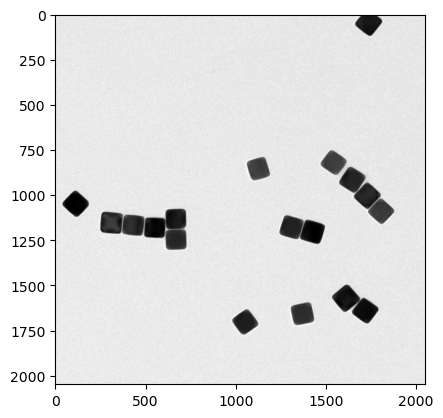

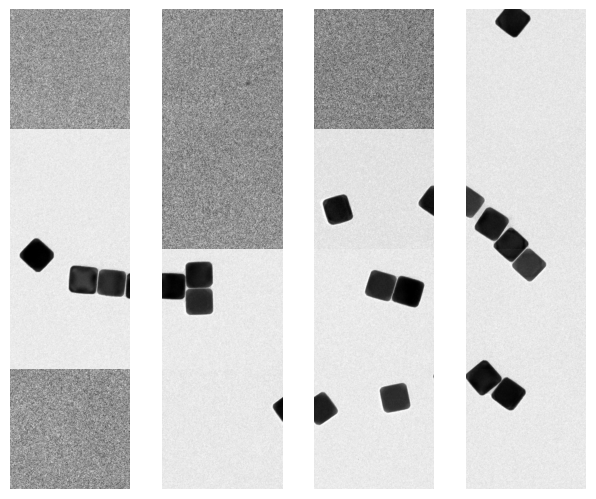

In [21]:
image_dummy = s.data
dim_xo,dim_y0 = np.shape(s.data)
dim_x = 512
num_images = (dim_xo//dim_x)**2
print(num_images)
import matplotlib.pyplot as plt
plt.imshow(image_dummy,cmap = 'grey')
multiplier = dim_xo//dim_x
print('multiplier =',multiplier)
fig, ax = plt.subplots(multiplier,multiplier)
for i in range(multiplier):
    for j in range(multiplier):
        img = image_dummy[dim_x*i:dim_x*(i+1),dim_x*j:dim_x*(j+1)]
        ax[i,j].imshow(img,cmap='gray')
        ax[i,j].axis('off')
plt.subplots_adjust(wspace=0, hspace=0)  
plt.margins(0)                            
plt.tight_layout(pad=0)                   
plt.show()